In [1]:
import os

import numpy as np

os.chdir('../../..')
print(os.getcwd())

/Users/titonka/FAIRIS


In [8]:
import pickle
import ipywidgets as widgets
from Simulation.libraries.SimulationLib.Environment import *
maze_file = 'WM00'
experiment_data = []
with open('logs/'+maze_file+'_test_no_noise_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_01_noise_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_05_noise_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_10_noise_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_10_decay_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_25_decay_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test_50_decay_V3','rb') as file:
    experiment_data.append(pickle.load(file))
with open('logs/'+maze_file+'_test2_no_noise_V3','rb') as file:
    experiment_data.append(pickle.load(file))

In [9]:
class ShortestPath:
    def __init__(self,maze_file,starting_points,path_lengths):
        self.maze_file = maze_file
        self.starting_points = starting_points
        self.path_lengths = {
            starting_points[0] : path_lengths[0],
            starting_points[1] : path_lengths[1],
            starting_points[2] : path_lengths[2],
            starting_points[3] : path_lengths[3],
            starting_points[4] : path_lengths[4],
            starting_points[5] : path_lengths[5],
            starting_points[6] : path_lengths[6],
            starting_points[7] : path_lengths[7]
        }

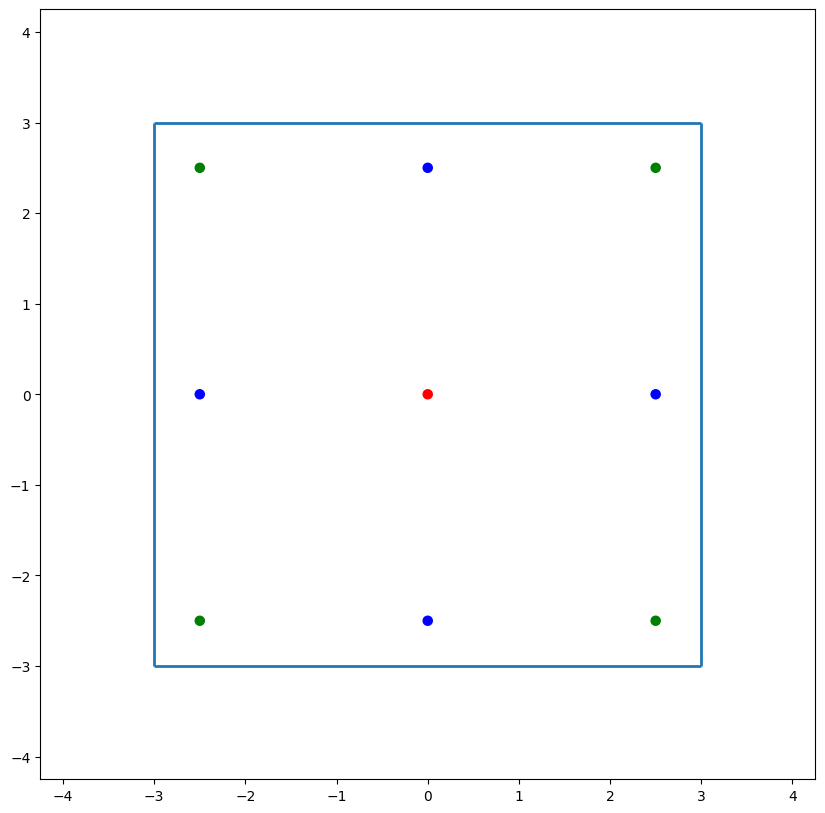

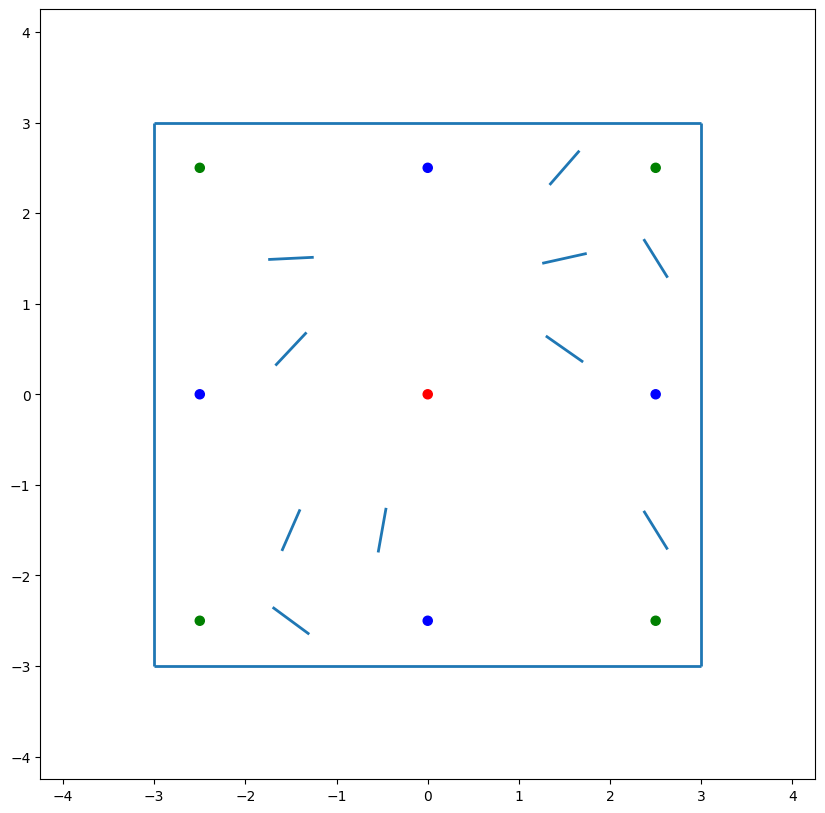

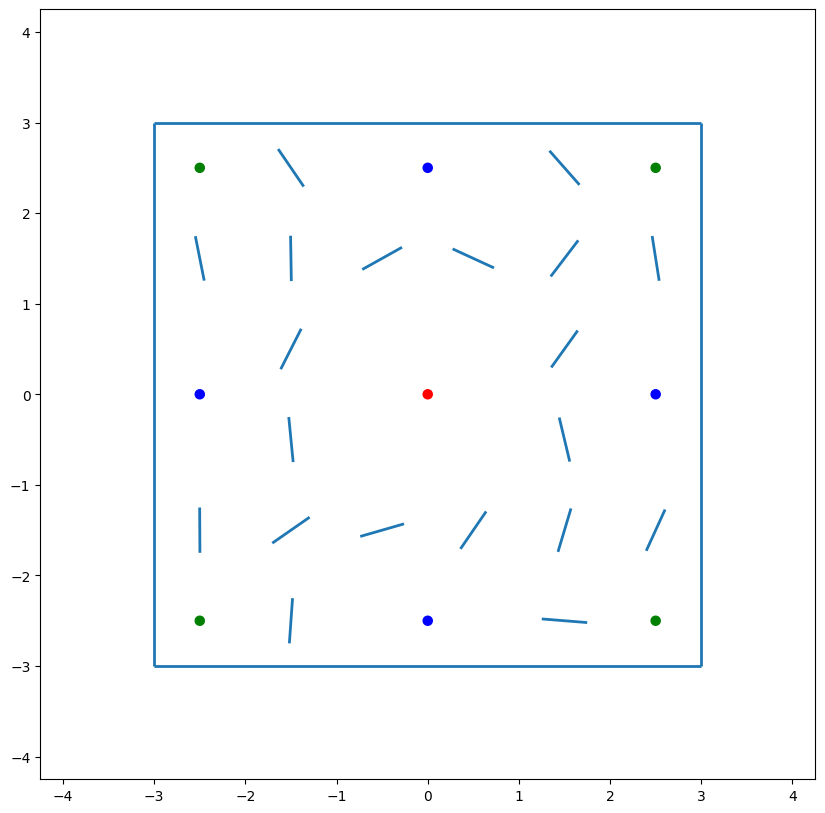

In [10]:
maze_files = ['WM00_paths.pkl','WM10_paths.pkl','WM20_paths.pkl']
mazes = []
for maze_file in maze_files:
    with open('Simulation/worlds/mazes/Experiment1/Paths/'+maze_file,'rb') as file:
        mazes.append(pickle.load(file))
maze_names = ['WM00','WM10','WM20']
path_data = []
name_index = 0
for maze in mazes:
    starting_points = []
    path_lengths = []
    for path in maze.paths:
        starting_points.append(path.path[0])
        path_lengths.append(len(path.path)-1)
    path_data.append(ShortestPath(maze_names[name_index],starting_points,path_lengths))
    name_index += 1

path_metrics = {
    'WM00': path_data[0],
    'WM10': path_data[1],
    'WM20': path_data[2]
}

In [11]:
optimality_ratios = []
for experiment in experiment_data:
    pc_ver = experiment.pc_dist.split('_')[1]
    maze_ver = experiment.maze_file
    shortest_path = path_metrics.get(maze_ver)
    temp = []
    for episode in experiment.episodes:
        start = (episode.path_xs[0] , episode.path_ys[0])
        min_dist = 100
        for s in shortest_path.starting_points:
            dist = math.sqrt((start[0] - s[0])**2 + (start[1]-s[1])**2)
            if dist < min_dist:
                min_dist = dist
                eps_start = s  
        min_length = int(shortest_path.path_lengths.get(eps_start))
        optimality_ratio = (episode.path_length - min_length)/min_length 
        temp.append(optimality_ratio)
    optimality_ratios.append(temp)

In [12]:
import numpy as np
print("PC noise 1%")
print("mean: ", np.mean(optimality_ratios[1]))
print("med: ", np.median(optimality_ratios[1]))
print("std: ", np.std(optimality_ratios[1]))
print("min: ", min(optimality_ratios[1]))
print("PC noise 5%")
print("mean: ", np.mean(optimality_ratios[2]))
print("med: ", np.median(optimality_ratios[2]))
print("std: ", np.std(optimality_ratios[2]))
print("min: ", min(optimality_ratios[2]))
print("PC noise 10%")
print("mean: ", np.mean(optimality_ratios[3]))
print("med: ", np.median(optimality_ratios[3]))
print("std: ", np.std(optimality_ratios[3]))
print("min: ", min(optimality_ratios[3]))

print("PC_decay 10%")
print("mean: ", np.mean(optimality_ratios[4]))
print("med: ", np.median(optimality_ratios[4]))
print("std: ", np.std(optimality_ratios[4]))
print("min: ", min(optimality_ratios[4]))
print("PC_decay 25%")
print("mean: ", np.mean(optimality_ratios[5]))
print("med: ", np.median(optimality_ratios[5]))
print("std: ", np.std(optimality_ratios[5]))
print("min: ", min(optimality_ratios[5]))
print("PC_decay 50%")
print("mean: ", np.mean(optimality_ratios[6]))
print("med: ", np.median(optimality_ratios[6]))
print("std: ", np.std(optimality_ratios[6]))
print("min: ", min(optimality_ratios[6]))

PC noise 1%
mean:  0.045
med:  0.0
std:  0.10805091392487154
min:  0.0
PC noise 5%
mean:  1.301
med:  0.9
std:  1.6301837319762456
min:  0.0
PC noise 10%
mean:  2.921
med:  1.9
std:  2.8045425651966847
min:  0.0
PC_decay 10%
mean:  0.16400000000000003
med:  0.0
std:  0.3189106457928302
min:  0.0
PC_decay 25%
mean:  0.43699999999999994
med:  0.1
std:  0.7868487783557905
min:  0.0
PC_decay 50%
mean:  2.7880000000000003
med:  0.7
std:  5.50294975444988
min:  0.0


In [19]:
print(optimality_ratios[3])

[0.45454545454545453, 6.5, 2.0, 12.272727272727273, 2.090909090909091, 3.909090909090909, 8.5, 4.363636363636363, 3.8181818181818183, 17.7, 2.3636363636363638, 1.2727272727272727, 0.8181818181818182, 2.1818181818181817, 3.727272727272727, 17.0, 2.5454545454545454, 3.8, 9.363636363636363, 1.8181818181818181, 5.3, 3.3636363636363638, 0.6363636363636364, 4.636363636363637, 3.6, 3.5454545454545454, 3.727272727272727, 2.5454545454545454, 1.4, 2.4545454545454546, 3.6363636363636362, 4.545454545454546, 2.3636363636363638, 4.2727272727272725, 21.1, 1.0909090909090908, 2.090909090909091, 1.4545454545454546, 3.4, 3.0, 1.5, 4.7272727272727275, 4.0, 2.090909090909091, 2.1, 5.0, 3.909090909090909, 0.36363636363636365, 0.45454545454545453, 1.1818181818181819, 2.3636363636363638, 2.1, 10.5, 1.7272727272727273, 2.0, 1.9090909090909092, 0.7272727272727273, 0.9090909090909091, 6.181818181818182, 17.9, 5.9, 8.090909090909092, 5.181818181818182, 1.0, 0.6363636363636364, 3.4545454545454546, 8.5, 1.36363636

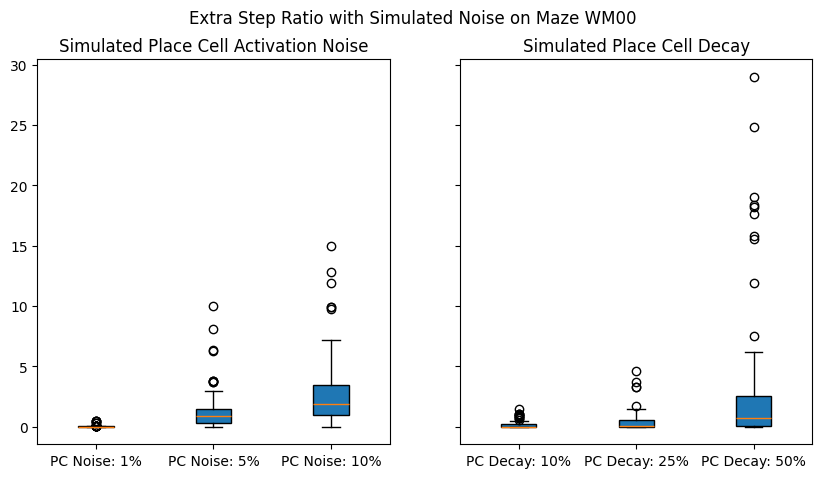

In [24]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, sharey = True, figsize = (10, 5))

ax1.boxplot([optimality_ratios[1],optimality_ratios[2],optimality_ratios[3]],patch_artist=True,
                notch=False)
ax1.set_xticklabels(['PC Noise: 1%', 'PC Noise: 5%','PC Noise: 10%'])
ax1.set_title('Simulated Place Cell Activation Noise')

ax2.boxplot([optimality_ratios[4],optimality_ratios[5],optimality_ratios[6]],patch_artist=True,
                notch=False)
ax2.set_xticklabels(['PC Decay: 10%', 'PC Decay: 25%','PC Decay: 50%'])
ax2.set_title('Simulated Place Cell Decay')


plt.suptitle('Extra Step Ratio with Simulated Noise on Maze WM00')
fig.savefig('Simulation/DataCache/UniformResults/WM00_Noise_ESR.png')
plt.show()

In [34]:
def plot_last_paths(experiment_data):
    maze_figure, maze_figure_ax = plt.subplots(1, 1, figsize=(6, 6))
    maze = Maze('Simulation/worlds/mazes/Experiment1/'+experiment_data.maze_file+'.xml')
    maze_figure_ax.add_collection(pycol.LineCollection(maze.walls, linewidths=2))
    
    for point in maze.experiment_starting_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='green')
        maze_figure_ax.add_patch(new_crc)
    for point in maze.habituation_start_location:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='blue')
        maze_figure_ax.add_patch(new_crc)
    for point in maze.goal_locations:
        new_crc = patches.Circle((point.x, point.y), radius=.05, color='red')
        maze_figure_ax.add_patch(new_crc)
    start_index = 0
    min_score =100
    for i in list(range(0,len(experiment_data.path_length_history),4)):
        total = experiment_data.path_length_history[i] + experiment_data.path_length_history[i+1] + experiment_data.path_length_history[i+2] +experiment_data.path_length_history[i+3] 
        if total < min_score:
            start_index = i
            min_score = total

    maze_figure_ax.plot(experiment_data.episodes[start_index].path_xs,experiment_data.episodes[start_index].path_ys)
    maze_figure_ax.plot(experiment_data.episodes[start_index+1].path_xs,experiment_data.episodes[start_index+1].path_ys)
    maze_figure_ax.plot(experiment_data.episodes[start_index+2].path_xs,experiment_data.episodes[start_index+2].path_ys)
    maze_figure_ax.plot(experiment_data.episodes[start_index+3].path_xs,experiment_data.episodes[start_index+3].path_ys)
    maze_figure_ax.set_title("Unseen Locations")


    maze_figure_ax.set_ylim(-4.25, 4.25)
    maze_figure_ax.set_xlim(-4.25, 4.25)
    maze_figure_ax.margins(0.1)
    return maze_figure

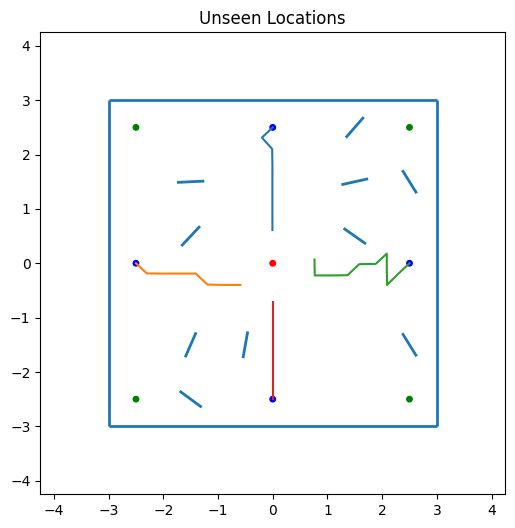

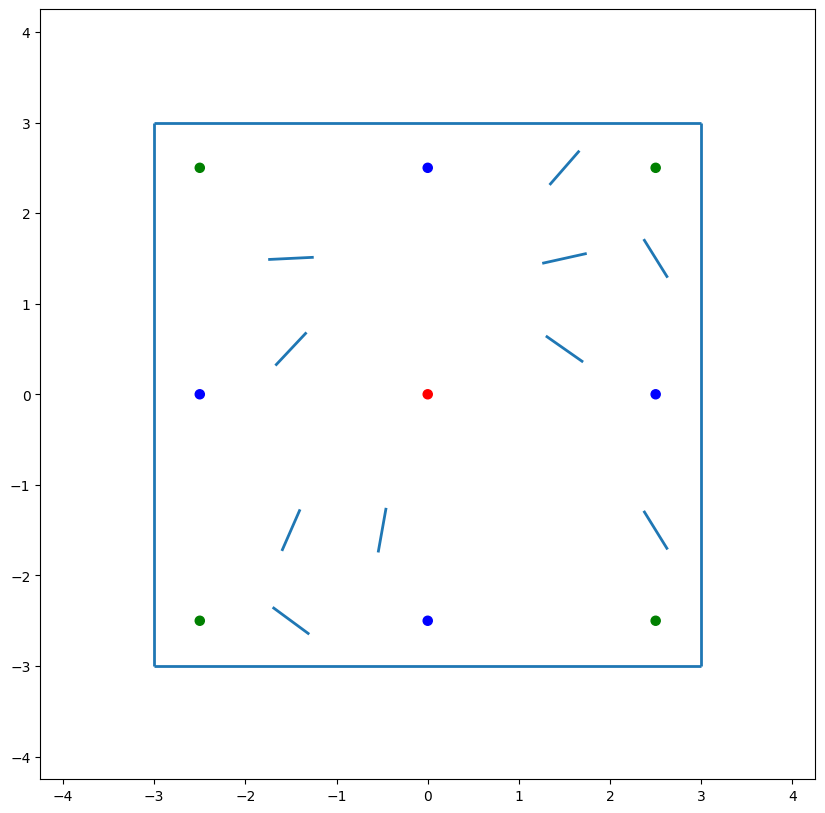

In [38]:
fig = plot_last_paths(experiment_data[-1])
fig.savefig('Simulation/DataCache/UniformResults/MW10_unseen_paths.png')